**Laster inn bibliotek:**

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.signal as sgn
import scipy.optimize as opt

**Definerer en funksjon for numerisk derivasjon (s. 191 i Mønster), som jeg vil bruke gjennom arbeidet:**

In [3]:
#Funksjonsbibliotek:
#Numerisk derivasjon:
def numderiv(x, y):
    derivertverdier = []
    for i in range(len(x)-1):
        x1 = x[i]
        x2 = x[i+1]
        y1 = y[i]
        y2 = y[i+1]
        delta_x = x2 - x1
        delta_y = y2 - y1
        derivert = delta_y/delta_x
        derivertverdier.append(derivert)
    return derivertverdier

#Lineær funksjon:
def linfunk(x, a, b):
    return a*x + b


**Laster inn datasett ved hjelp av Pandas (s. 189 i Mønster):**

In [15]:
#Laster inn datasett og oppretter lister:
df = pd.read_csv('havniva.csv', comment = "#", sep = ";", decimal = ".")
tid = df['Aar'].tolist()
nivaa = df['Havnivaa'].tolist()
df

,Aar,Havnivaa
0,1880,0.29
1,1881,0.85
2,1882,-0.83
3,1883,-0.30
4,1884,1.79
...,...,...
134,2014,23.10
135,2015,24.03
136,2016,24.40
137,2017,24.54


**Tegner dataen:**

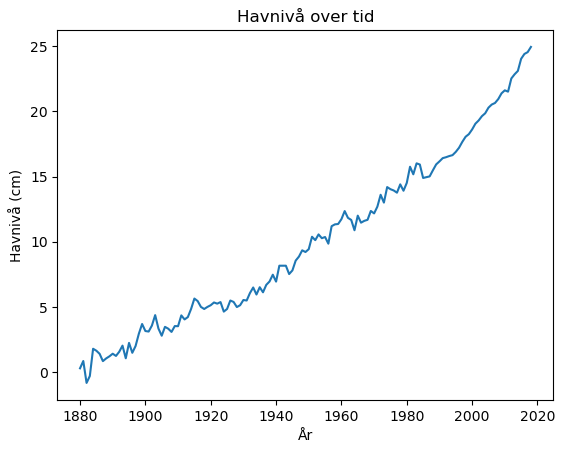

In [16]:
plt.plot(tid, nivaa)
plt.title('Havnivå over tid')
plt.xlabel('År')
plt.ylabel('Havnivå (cm)')
plt.show()

Umiddelbare tanker: 
 - Havnivået stiger.
 - Lineært? Eller ser det ut som det stiger raskere og raskere? -> Se på den deriverte!
 - Mulig problemstilling:
 - - Stiger havnivået lineært, eller har stigningstallet endret seg over tid? 

**Deriverer ved hjelp av funksjonen min, og tegner den deriverte:**

In [6]:
derivertverdier = numderiv(tid, nivaa)

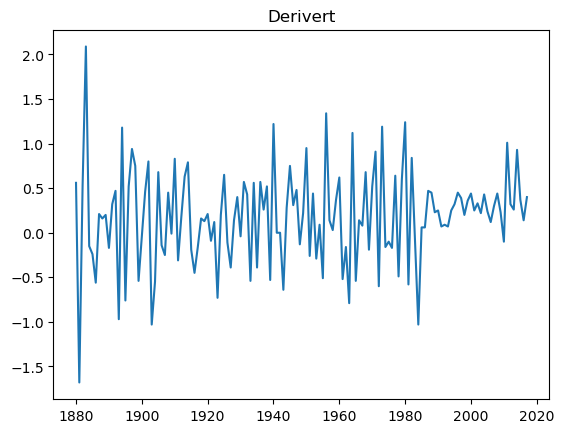

In [7]:
plt.plot(tid[:-1], derivertverdier)
plt.title('Derivert')
plt.show()

**Ikke så lett å tolke noe som helst fra dette... mye støy...**

Bruker et filter for å redusere støy (jeg kan hjelpe de gruppene som evt. trenger dette)

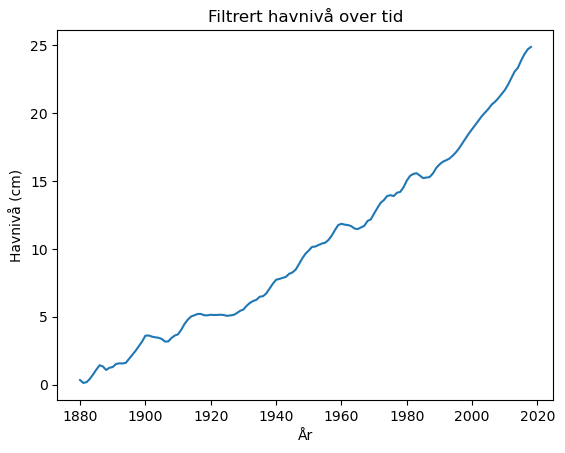

In [12]:
plt.plot(tid, filtered)
plt.title('Filtrert havnivå over tid')
plt.xlabel('År')
plt.ylabel('Havnivå (cm)')
plt.show()

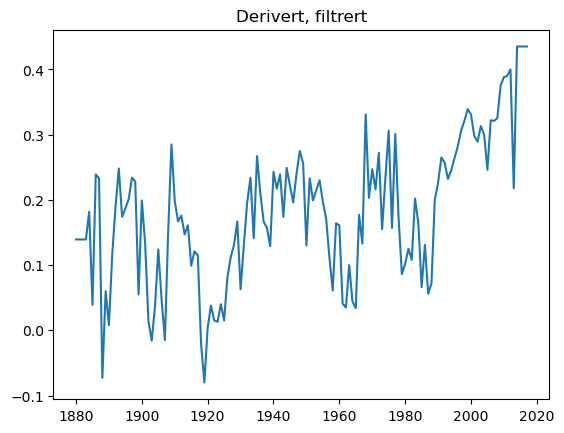

In [69]:
derivertverdier = numderiv(tid, filtered)
plt.plot(tid[:-1], derivertverdier)
plt.title('Derivert, filtrert')
plt.show()

Hmm... hjalp kanskje litt? Frem til 1985 - støy om et gjennomsnitt. Etter 1985, stigningstallet øker?
**Ser i alle fall ut til å stigningstallet begynner å øke på et tidspunkt! - > svarer på noe av min problemstilling?**

In [70]:
#Beregner gjennomsnitt, første 105 år:
sum = 0
for i in range(105):
    sum = sum + derivertverdier[i]
df = sum / 105
print(df)

0.14628311688311693


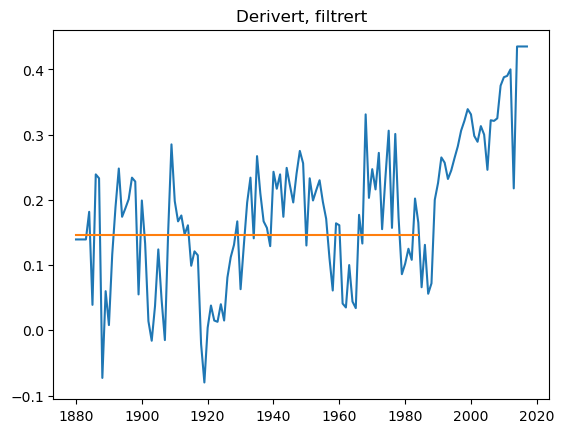

In [71]:
plt.plot(tid[:-1], derivertverdier)
plt.plot(tid[0:105], np.ones(105)*df)
plt.title('Derivert, filtrert')
plt.show()

Kan vi modellere endringen i den deriverte etter 1985 som en lineær funksjon? Andrederivert!

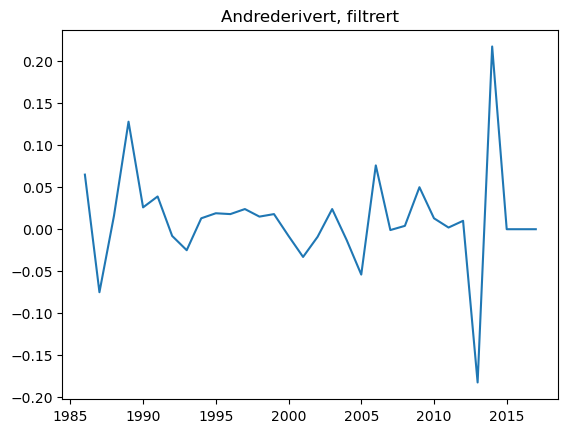

In [77]:
andrederivertverdier = numderiv(tid[:-1], derivertverdier)
plt.plot(tid[106:-1], andrederivertverdier[105:])
plt.title('Andrederivert, filtrert')
plt.show()

In [78]:
#Beregner gjennomsnitt, siste 33 år:
sum = 0
for i in range(33):
    sum = sum + andrederivertverdier[104 + i]
ddf = sum / 33
print(ddf)

0.008184573002754762


Gjennomsnittlig verdi på den andrederiverte: 0.29. 
Kan den deriverte modelleres som en lineær funksjon med stigningstall 0.29 fra 1985?

In [79]:
test = linfunk(np.arange(0, 33, 1), ddf, df) 

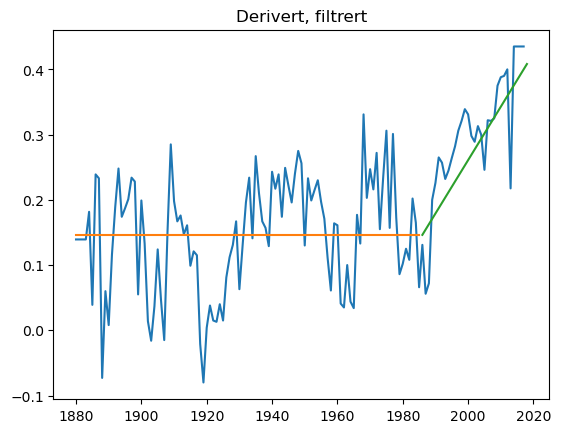

In [80]:
plt.plot(tid[:-1], derivertverdier)
plt.plot(tid[0:106], np.ones(106)*df)
plt.plot(tid[106:], test)
plt.title('Derivert, filtrert')
plt.show()

Hmmm... ser kanskje OK ut? Kan vi bruke dette til å modellere den opprinnelige dataen? Lineær vekst frem til 1985, vekst som andregradsfunksjon etter 1985?

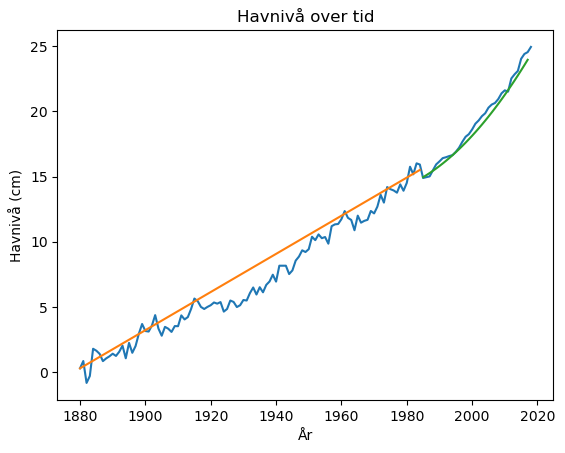

In [81]:
#1880 til 1985:
xverdier1 = []
yverdier1 = []
x = 0
y = nivaa[0]
for i in range(105):
    xverdier1.append(x+1880)
    yverdier1.append(y)
    x = x + 1
    y = linfunk(x, df, nivaa[0])

#Bruker Eulers metode til å modellere andregrafsfunksjonen
#1985 til 2018:
xverdier2 = []
yverdier2 = []
x = 0
y = nivaa[106]
for i in range(33):
    xverdier2.append(x+1985)
    yverdier2.append(y)
    x = x + 1
    y = y + linfunk(x, ddf, df)

plt.plot(tid, nivaa)
plt.plot(xverdier1, yverdier1)
plt.plot(xverdier2, yverdier2)
plt.title('Havnivå over tid')
plt.xlabel('År')
plt.ylabel('Havnivå (cm)')
plt.show()
    

Ser kanskje ikke så ille ut?